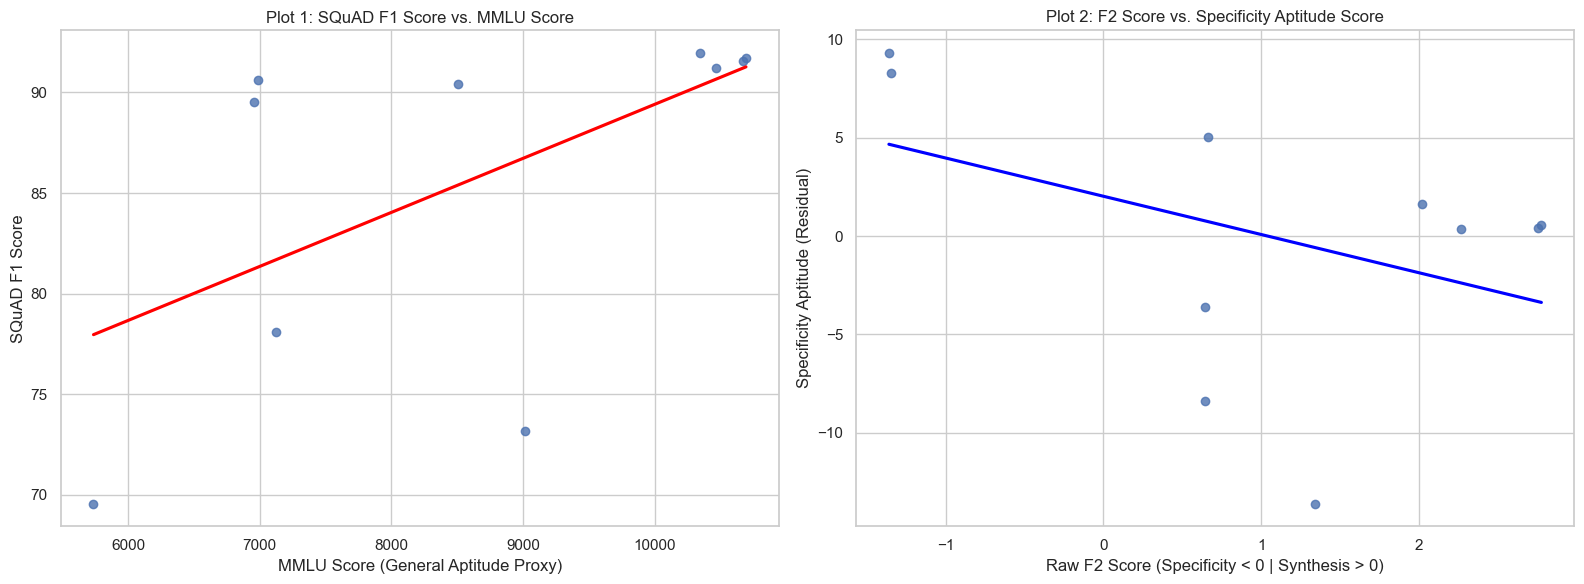


--- Final Data with MMLU-based Aptitude Scores ---
                                 model  f2_raw     mmlu  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359   6989.0     90.64    81.324577        9.315423
0          llama-3.1-8b-instruct-turbo  -1.343   6953.0     89.51    81.227907        8.282093
2                           llama-2-7b   0.645   5738.0     69.57    77.965307       -8.395307
3                          llama-2-13b   0.645   7126.0     78.09    81.692458       -3.602458
4                           llama-3-8b   0.662   8502.0     90.44    85.387386        5.052614
5                          llama-2-70b   1.343   9018.0     73.16    86.772984      -13.612984
6                          llama-3-70b   2.015  10346.0     91.96    90.339019        1.620981
7         llama-3.1-70b-instruct-turbo   2.265  10667.0     91.54    91.200990        0.339010
8  llama-3.2-90b-vision-instruct-turbo   2.752  10692.0     91.70    91.268121        0.43187

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the final, complete dataset
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'mmlu': [6953.0, 6989.0, 5738.0, 7126.0, 8502.0, 9018.0, 10346.0, 10667.0, 10692.0, 10466.0],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using MMLU as the capability proxy
X = df[['mmlu']]  # <-- Using MMLU as the independent variable
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the definitive "Specificity Aptitude Score"
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. MMLU score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='mmlu', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. MMLU Score')
plt.xlabel('MMLU Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The isolated relationship, now using the best proxy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')

plt.tight_layout()
plt.show()

# 4. Print the final DataFrame
print("\n--- Final Data with MMLU-based Aptitude Scores ---")
print(df.sort_values(by='f2_raw').to_string())

# Add this after creating the final dataframe 'df'
correlation = df['f2_raw'].corr(df['aptitude_score'])
print(f"\nCorrelation between F2 Score and Specificity Aptitude: {correlation:.4f}")

# Comparison with MMLU PC1

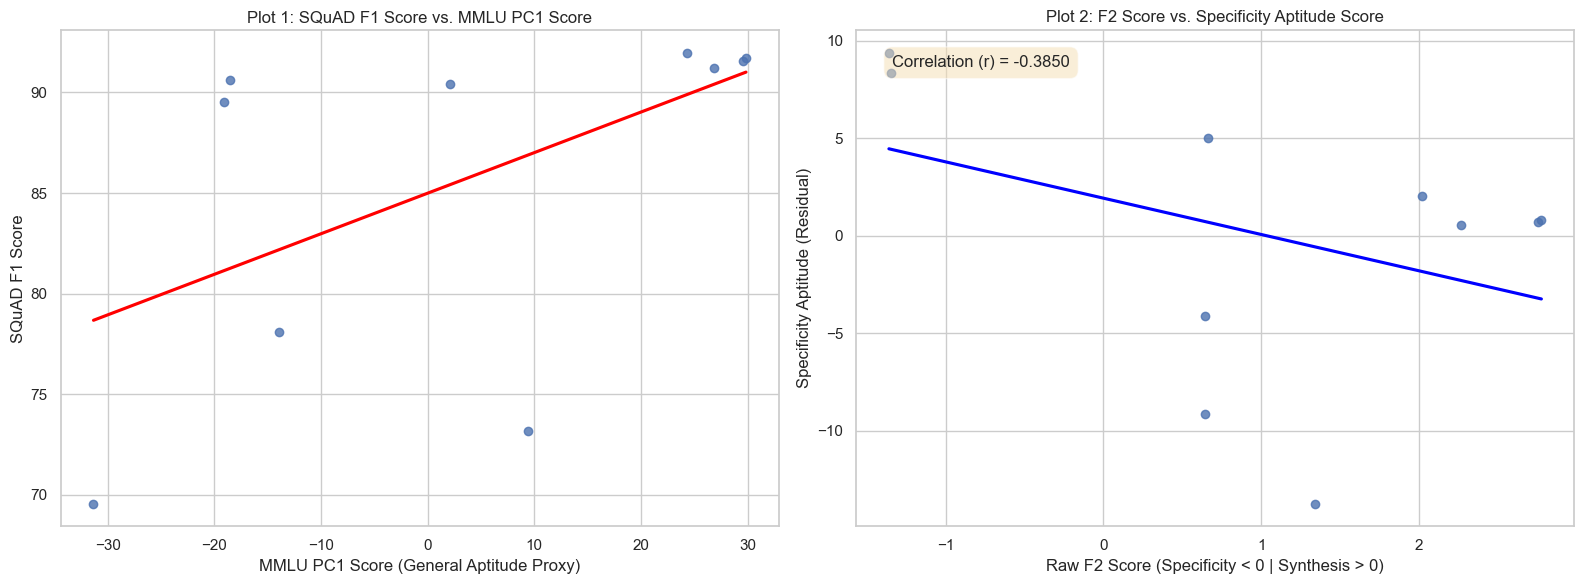


--- Final Data with MMLU PC1-based Aptitude Scores ---
                                 model  f2_raw  mmlu_pc1  squad_f1  expected_f1  aptitude_score
1  llama-3.2-11b-vision-instruct-turbo  -1.359   -18.559     90.64    81.252940        9.387060
0          llama-3.1-8b-instruct-turbo  -1.343   -19.095     89.51    81.144939        8.365061
2                           llama-2-7b   0.645   -31.332     69.57    78.679243       -9.109243
3                          llama-2-13b   0.645   -13.935     78.09    82.184653       -4.094653
4                           llama-3-8b   0.662     2.109     90.44    85.417440        5.022560
5                          llama-2-70b   1.343     9.418     73.16    86.890168      -13.730168
6                          llama-3-70b   2.015    24.337     91.96    89.896273        2.063727
7         llama-3.1-70b-instruct-turbo   2.265    29.618     91.54    90.960368        0.579632
8  llama-3.2-90b-vision-instruct-turbo   2.752    29.850     91.70    91.007115 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load the data with the MMLU PC1 scores
# I've transcribed the PC1 scores from your image.
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'mmlu_pc1': [-19.095, -18.559, -31.332, -13.935, 2.109, 9.418, 24.337, 29.618, 29.850, 26.871],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using MMLU PC1 as the capability proxy
X = df[['mmlu_pc1']]  # <-- Using the new, more precise proxy
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the most precise "Specificity Aptitude Score" yet
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: F1 score vs. MMLU PC1 score
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='mmlu_pc1', y='squad_f1', ci=None, line_kws={"color": "red"})
plt.title('Plot 1: SQuAD F1 Score vs. MMLU PC1 Score')
plt.xlabel('MMLU PC1 Score (General Aptitude Proxy)')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The definitive isolated relationship
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
# Calculate and display the correlation coefficient on the plot
correlation = df['f2_raw'].corr(df['aptitude_score'])
plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')

plt.tight_layout()
plt.show()

# 4. Print the final DataFrame
print("\n--- Final Data with MMLU PC1-based Aptitude Scores ---")
print(df.sort_values(by='f2_raw').to_string())

# Comparison relative to model size

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load your data into a pandas DataFrame
# I've combined the data from your F2 score image and the SQuAD F1 scores.
data = {
    'model': [
        'llama-3.1-8b-instruct-turbo',
        'llama-3.2-11b-vision-instruct-turbo',
        'llama-2-7b',
        'llama-2-13b',
        'llama-3-8b',
        'llama-2-70b',
        'llama-3-70b',
        'llama-3.1-70b-instruct-turbo',
        'llama-3.2-90b-vision-instruct-turbo',
        'llama-3.3-70b-instruct-turbo'
    ],
    'size_b': [8, 11, 7, 13, 8, 70, 70, 70, 90, 70],
    'f2_raw': [-1.343, -1.359, 0.645, 0.645, 0.662, 1.343, 2.015, 2.265, 2.752, 2.774],
    'squad_f1': [89.51, 90.64, 69.57, 78.09, 90.44, 73.16, 91.96, 91.54, 91.70, 91.23]
}
df = pd.DataFrame(data)

# 2. Model Expected Performance using Linear Regression
# We'll use the log of model size as a better proxy for capability, as performance
# doesn't scale linearly with parameter count.
X = np.log(df[['size_b']]) 
y = df['squad_f1']

# Fit the regression model
reg = LinearRegression().fit(X, y)
df['expected_f1'] = reg.predict(X)

# 3. Calculate the "Specificity Aptitude Score" (the residual)
# This score shows how much a model over/under-performs for its size.
df['aptitude_score'] = df['squad_f1'] - df['expected_f1']

# --- Visualization and Conclusion ---

# Set up the plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: The Problem - F1 score is confounded by model size
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='size_b', y='squad_f1', logx=True, ci=None, line_kws={"color": "red"})
# Annotate each point with the model name for clarity
for i in range(df.shape[0]):
    plt.text(df['size_b'][i] * 1.1, df['squad_f1'][i], df['model'][i].replace('meta/llama-', '').replace('-instruct-turbo',''), fontsize=8, alpha=0.75)
plt.title('Plot 1: F1 Score vs. Model Size (Log Scale)')
plt.xlabel('Model Size (Billions of Parameters) - Log Scale')
plt.ylabel('SQuAD F1 Score')

# Plot 2: The Solution - The clear relationship emerges
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='f2_raw', y='aptitude_score', ci=None, line_kws={"color": "blue"})
# Annotate each point
for i in range(df.shape[0]):
    plt.text(df['f2_raw'][i] + 0.05, df['aptitude_score'][i], df['model'][i].replace('meta/llama-', '').replace('-instruct-turbo',''), fontsize=8, alpha=0.75)
plt.title('Plot 2: F2 Score vs. Specificity Aptitude Score')
plt.xlabel('Raw F2 Score (Specificity < 0 | Synthesis > 0)')
plt.ylabel('Specificity Aptitude (Residual)')

plt.tight_layout()
plt.show()

# 4. Print the final DataFrame and Conclusion
print("\n--- Final Data with Aptitude Scores ---")
print(df.sort_values(by='f2_raw').to_string())

print("\n--- Conclusion ---")
print("""
1. Plot 1 clearly shows the problem: SQuAD F1 score generally increases with model size. The red line represents the 'expected' performance for a model of a given size.

2. Plot 2 shows the solution. By plotting the raw F2 score against the 'Specificity Aptitude Score' (the residuals from Plot 1), we isolate the model's tendency.

3. The result is a strong, clear, linear negative correlation. This numerically demonstrates that as a model's F2 score becomes more negative, its specialized aptitude for specificity tasks (like SQuAD) increases dramatically, independent of its general size and power. Conversely, models with high positive F2 scores, like Llama-2-70b, show a strong negative aptitude for this task compared to what their size would predict.
""")